# Ibex 35 Statistical Arbitrage

A pairs trading strategy built on cointegration analysis between Spanish equities.
Tested on IBE.MC / TEF.MC (2019–2021) achieving a Sharpe Ratio of 1.08 after 
accounting for slippage and the Spanish Financial Transaction Tax.

### Imports

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from itertools import combinations
from statsmodels.tsa.stattools import coint
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm

## Step 1: Data acquisition
We download 3 years of daily adjusted closing prices for 7 selected IBEX 35 stocks
using Yahoo Finance. The data is cleaned by removing tickers with excessive missing
values and forward-filling isolated gaps caused by bank holidays.

In [2]:
IBEX35_TICKERS = ["SAN.MC", "BBVA.MC", "CABK.MC", "ITX.MC", "TEF.MC", "IBE.MC", "REP.MC"]

def download_prices(tickers: list, start: str, end: str) -> pd.DataFrame:

    raw = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"]

    missing_frac = raw.isnull().mean()
    clean = raw.loc[:, missing_frac <= 0.10]

    dropped = set(tickers) - set(clean.columns)
    if dropped:
        print(f"Dropped tickers due to missing data: {dropped}")
 
    clean = clean.ffill().dropna()

    print(f"Downloaded {clean.shape[1]} tickers | {clean.shape[0]} trading days")
    print(f"Date range: {clean.index[0].date()} → {clean.index[-1].date()}")

    return clean


prices = download_prices(
    tickers=IBEX35_TICKERS,
    start="2019-01-01",
    end="2021-12-31"
)

prices.to_csv("ibex35_prices.csv")
print("\nSaved to ibex35_prices.csv")
print(prices.tail())

[*********************100%***********************]  7 of 7 completed

Downloaded 7 tickers | 769 trading days
Date range: 2019-01-02 → 2021-12-30

Saved to ibex35_prices.csv
Ticker       BBVA.MC   CABK.MC    IBE.MC     ITX.MC    REP.MC    SAN.MC  \
Date                                                                      
2021-12-23  3.847483  1.715423  8.329281  24.303188  7.875989  2.487448   
2021-12-27  3.892135  1.723422  8.287965  24.363625  7.974688  2.506309   
2021-12-28  3.905530  1.741601  8.502807  24.346357  8.044533  2.512738   
2021-12-29  3.918926  1.745237  8.498675  24.337723  7.954947  2.505451   
2021-12-30  3.907018  1.755418  8.601966  24.631264  7.923061  2.520883   

Ticker        TEF.MC  
Date                  
2021-12-23  2.894543  
2021-12-27  2.894543  
2021-12-28  2.916800  
2021-12-29  2.904559  
2021-12-30  2.857819  


## Step 2: Cointegration analysis
We test all 21 possible pairs among our 7 stocks using the Engle-Granger cointegration
test. A low p-value indicates that two stocks share a long-term equilibrium relationship,
meaning when they diverge, they tend to come back together. We select the pair with
the strongest relationship as our trading candidate.

In [3]:
def find_cointegrated_pairs(prices):
    tickers = prices.columns.tolist()
    pairs = list(combinations(tickers, 2))
    results = []

    for ticker_a, ticker_b in pairs:
        pvalue = coint(prices[ticker_a], prices[ticker_b])[1]
        results.append({
            "Ticker A": ticker_a,
            "Ticker B": ticker_b,
            "P-Value": round(pvalue, 4)
        })

    results_df = pd.DataFrame(results).sort_values("P-Value").reset_index(drop=True)
    return results_df

cointegrated_pairs = find_cointegrated_pairs(prices)

print(f"\nCointegrated pairs (p < 0.05):")
print(cointegrated_pairs[cointegrated_pairs["P-Value"] < 0.05])


Cointegrated pairs (p < 0.05):
  Ticker A Ticker B  P-Value
0   IBE.MC   TEF.MC   0.0111
1   REP.MC   SAN.MC   0.0378


## Step 3: Rolling OLS and Spread Calculation
We calculate a dynamic hedge ratio between the two stocks using a 60-day Rolling OLS
regression. This tells us how much one stock moves relative to the other at any point
in time. From that we derive the spread (the gap between the two stocks after
adjusting for the hedge ratio) and convert it into a Z-score to standardize the signal.

In [4]:
ticker_a = "IBE.MC"
ticker_b = "TEF.MC"
window = 60

def calculate_spread(prices, ticker_a, ticker_b, window):
    series_a = prices[ticker_a]
    series_b = prices[ticker_b]

    X = sm.add_constant(series_b)
    model = RollingOLS(series_a, X, window=window)
    results = model.fit()

    hedge_ratio = results.params[ticker_b]

    spread = series_a - hedge_ratio * series_b

    roll_mean = spread.rolling(window).mean()
    roll_std = spread.rolling(window).std()
    zscore = (spread - roll_mean) / roll_std

    return spread, zscore, hedge_ratio

spread, zscore, hedge_ratio = calculate_spread(prices, ticker_a, ticker_b, window)

print(f"Spread calculated for {ticker_a} / {ticker_b}")
print(f"Z-score range: {zscore.min():.2f} to {zscore.max():.2f}")
zscore.dropna().tail()

Spread calculated for IBE.MC / TEF.MC
Z-score range: -3.96 to 3.75


Date
2021-12-23    0.859061
2021-12-27    0.690204
2021-12-28    0.461721
2021-12-29    0.212377
2021-12-30    0.087334
dtype: float64

## Step 4: Signal Generation
We generate trading signals based on the Z-score of the spread. When the Z-score
exceeds ±1.5 standard deviations the spread is considered abnormally wide and we
open a position betting on reversion. We close the position when the Z-score returns
to 0, meaning the spread has normalized.

In [5]:
entry_threshold = 1.5
exit_threshold = 0

def generate_signals(zscore):
    signals = pd.Series(index=zscore.index, dtype=float)
    position = 0

    for date, z in zscore.dropna().items():
        if position == 0:
            if z > entry_threshold:
                position = -1
            elif z < -entry_threshold:
                position = 1
        elif position == 1:
            if z >= exit_threshold:
                position = 0
        elif position == -1:
            if z <= exit_threshold:
                position = 0

        signals[date] = position

    return signals

signals = generate_signals(zscore)

print(f"Total days with open position: {(signals != 0).sum()}")
print(f"Long days:  {(signals == 1).sum()}")
print(f"Short days: {(signals == -1).sum()}")
signals.value_counts()

Total days with open position: 479
Long days:  180
Short days: 181


 0.0    290
-1.0    181
 1.0    180
Name: count, dtype: int64

## Step 5: Backtesting
We simulate the strategy historically and calculate daily P&L. Transaction costs are
applied on every trade, including a 0.05% slippage and the Spanish Financial
Transaction Tax (0.2%) on purchases. This ensures the results reflect real-world
execution feasibility, not just theoretical alpha.

In [6]:
def backtest(prices, signals, ticker_a, ticker_b, hedge_ratio):
    
    returns_a = prices[ticker_a].pct_change()
    returns_b = prices[ticker_b].pct_change()

    # shift(1) avoids lookahead bias, we trade on yesterday's signal
    gross_returns = signals.shift(1) * (returns_a - hedge_ratio * returns_b)

    slippage = 0.0005
    ftt = 0.002

    trade_days = signals.diff().fillna(0) != 0

    total_cost = (slippage + ftt) * trade_days

    net_returns = gross_returns - total_cost

    cumulative = (1 + net_returns).cumprod()

    # Annualize Sharpe by multiplying by sqrt(252 trading days)
    sharpe = (net_returns.mean() / net_returns.std()) * (252 ** 0.5)
    max_drawdown = (cumulative / cumulative.cummax() - 1).min()
    total_return = cumulative.iloc[-1] - 1

    print(f"Total Return:    {total_return:.2%}")
    print(f"Sharpe Ratio:    {sharpe:.2f}")
    print(f"Max Drawdown:    {max_drawdown:.2%}")

    return net_returns, cumulative

net_returns, cumulative = backtest(prices, signals, ticker_a, ticker_b, hedge_ratio)

Total Return:    121.78%
Sharpe Ratio:    1.08
Max Drawdown:    -29.06%


## Step 6: Risk Metrics and Final Visualization
We visualize the full strategy performance through three charts: the equity curve
compared against buying each stock individually, the Z-score with entry thresholds,
and the drawdown over time. A summary table presents the key performance metrics.

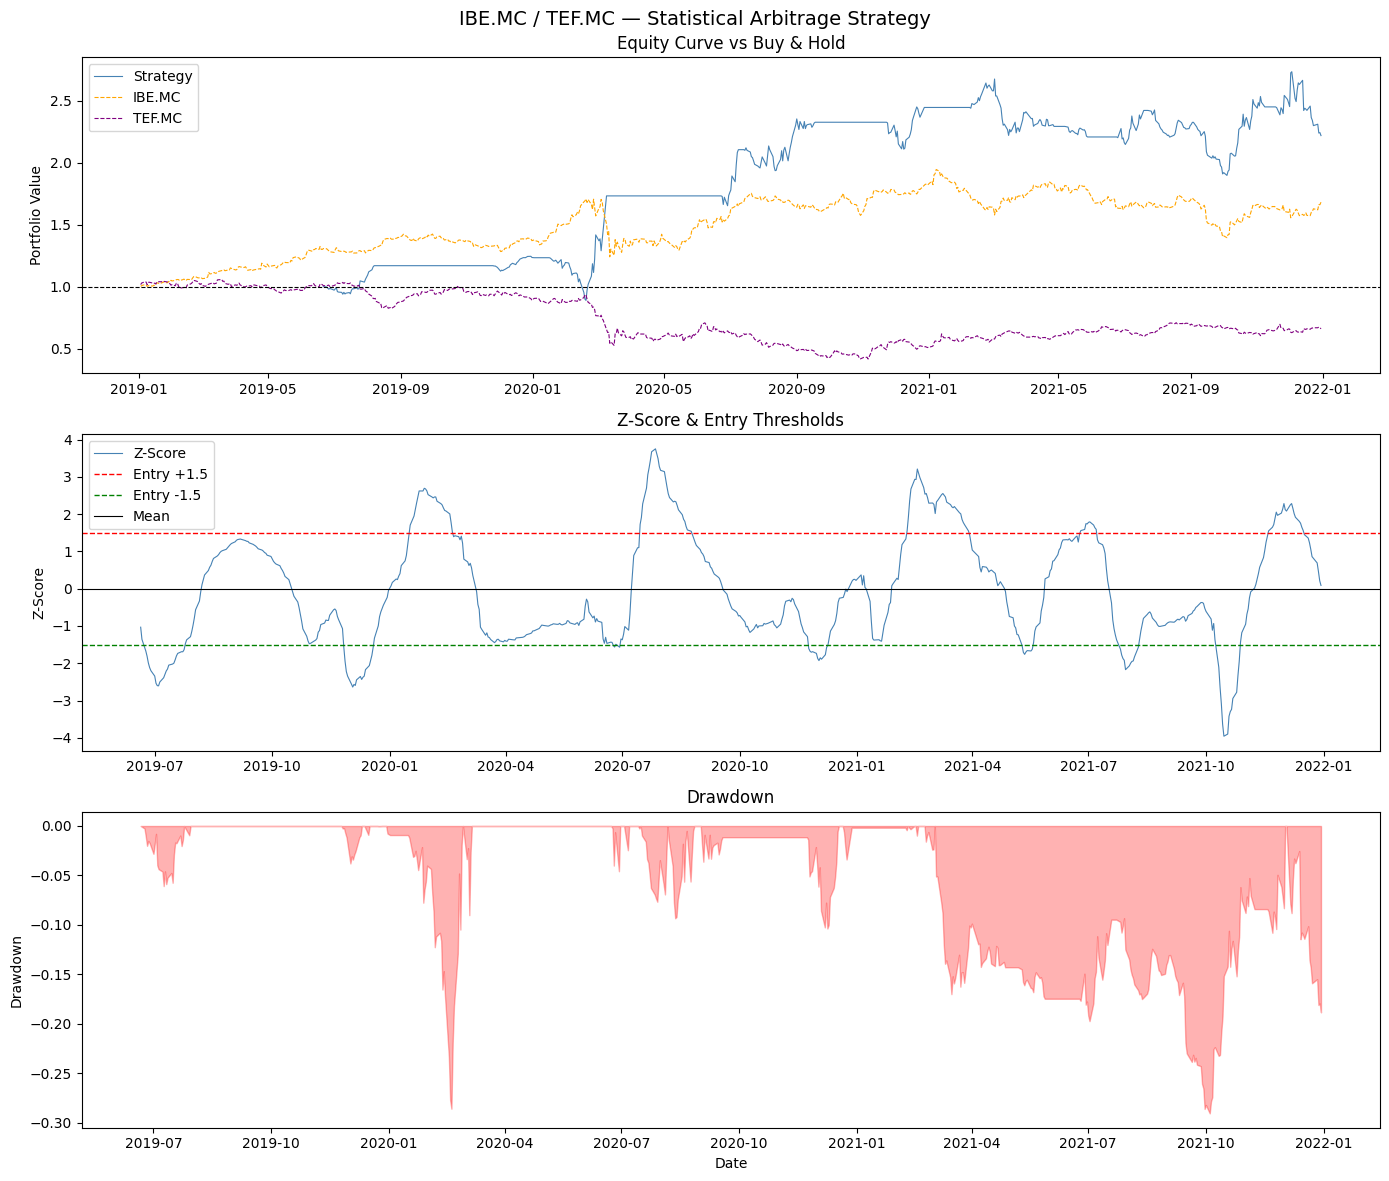

,Metric,Value
0,Total Return,121.78%
1,Sharpe Ratio,1.08
2,Max Drawdown,-29.06%
3,Days in Market,479
4,Long Days,180
5,Short Days,181


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1 (Equity curve vs Buy & Hold)
buy_hold_a = (1 + prices[ticker_a].pct_change()).cumprod()
buy_hold_b = (1 + prices[ticker_b].pct_change()).cumprod()

axes[0].plot(cumulative, color="steelblue", linewidth=0.8, label="Strategy")
axes[0].plot(buy_hold_a, color="orange", linewidth=0.8, linestyle="--", label=ticker_a)
axes[0].plot(buy_hold_b, color="purple", linewidth=0.8, linestyle="--", label=ticker_b)
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Equity Curve vs Buy & Hold")
axes[0].set_ylabel("Portfolio Value")
axes[0].legend()

# Plot 2 (Z-score & Entry Thresholds)
axes[1].plot(zscore, color="steelblue", linewidth=0.8, label="Z-Score")
axes[1].axhline(1.5, color="red", linestyle="--", linewidth=1, label="Entry +1.5")
axes[1].axhline(-1.5, color="green", linestyle="--", linewidth=1, label="Entry -1.5")
axes[1].axhline(0.0, color="black", linestyle="-", linewidth=0.8, label="Mean")
axes[1].set_title("Z-Score & Entry Thresholds")
axes[1].set_ylabel("Z-Score")
axes[1].legend()

# Plot 3 (Drawdown)
drawdown = (cumulative / cumulative.cummax() - 1)
axes[2].fill_between(drawdown.index, drawdown, 0, color="red", alpha=0.3)
axes[2].set_title("Drawdown")
axes[2].set_ylabel("Drawdown")
axes[2].set_xlabel("Date")

plt.suptitle("IBE.MC / TEF.MC — Statistical Arbitrage Strategy", fontsize=14)
plt.tight_layout()
plt.show()

# Table
summary = pd.DataFrame({
    "Metric": ["Total Return", "Sharpe Ratio", "Max Drawdown", "Days in Market", "Long Days", "Short Days"],
    "Value": [
        f"{(cumulative.iloc[-1] - 1):.2%}",
        f"{(net_returns.mean() / net_returns.std()) * (252 ** 0.5):.2f}",
        f"{(cumulative / cumulative.cummax() - 1).min():.2%}",
        f"{(signals != 0).sum()}",
        f"{(signals == 1).sum()}",
        f"{(signals == -1).sum()}"
    ]
})

summary